# 1.6 Featured Data — Model Evaluation

Evaluate the trained model on the test set with detailed metrics, residual analysis, and feature importance.

**Steps:**
1. Load feature-ready data and trained model
2. Final evaluation on test set
3. Predicted vs Actual and residual analysis
4. Feature importance
5. Experiment summary

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_STATE = 42

## 1.6.1 Load Data and Trained Model

In [2]:
df = pd.read_csv('../shared/data/features/house_data_features.csv')

with open('../shared/data/features/feature_list.json', 'r') as f:
    FEATURE_COLS = json.load(f)

with open('../shared/models/experiment_results.json', 'r') as f:
    experiment_results = json.load(f)

best_model = joblib.load('../shared/models/best_model.joblib')
best_model_name = experiment_results['best_model']

X = df[FEATURE_COLS]
y = df['log_price']
y_original = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f'Loaded model: {best_model_name}')
print(f'Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples')

Loaded model: Gradient Boosting
Train: 67 samples, Test: 17 samples


## 1.6.2 Final Model Evaluation

In [3]:
y_pred_test_log = best_model.predict(X_test)
y_pred_test = np.expm1(y_pred_test_log)
y_test_orig = np.expm1(y_test)

test_r2 = r2_score(y_test_orig, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_test))
test_mae = mean_absolute_error(y_test_orig, y_pred_test)
test_mape = mean_absolute_percentage_error(y_test_orig, y_pred_test)

print(f"{'='*50}")
print(f"Final Evaluation: {best_model_name} (Tuned)")
print(f"{'='*50}")
print(f"  Test R2:   {test_r2:.4f}")
print(f"  Test RMSE: ${test_rmse:>12,.2f}")
print(f"  Test MAE:  ${test_mae:>12,.2f}")
print(f"  Test MAPE: {test_mape:.4f}")
print(f"{'='*50}")

Final Evaluation: Gradient Boosting (Tuned)
  Test R2:   0.9489
  Test RMSE: $   62,092.50
  Test MAE:  $   38,910.69
  Test MAPE: 0.0581


## 1.6.3 Predicted vs Actual and Residual Analysis

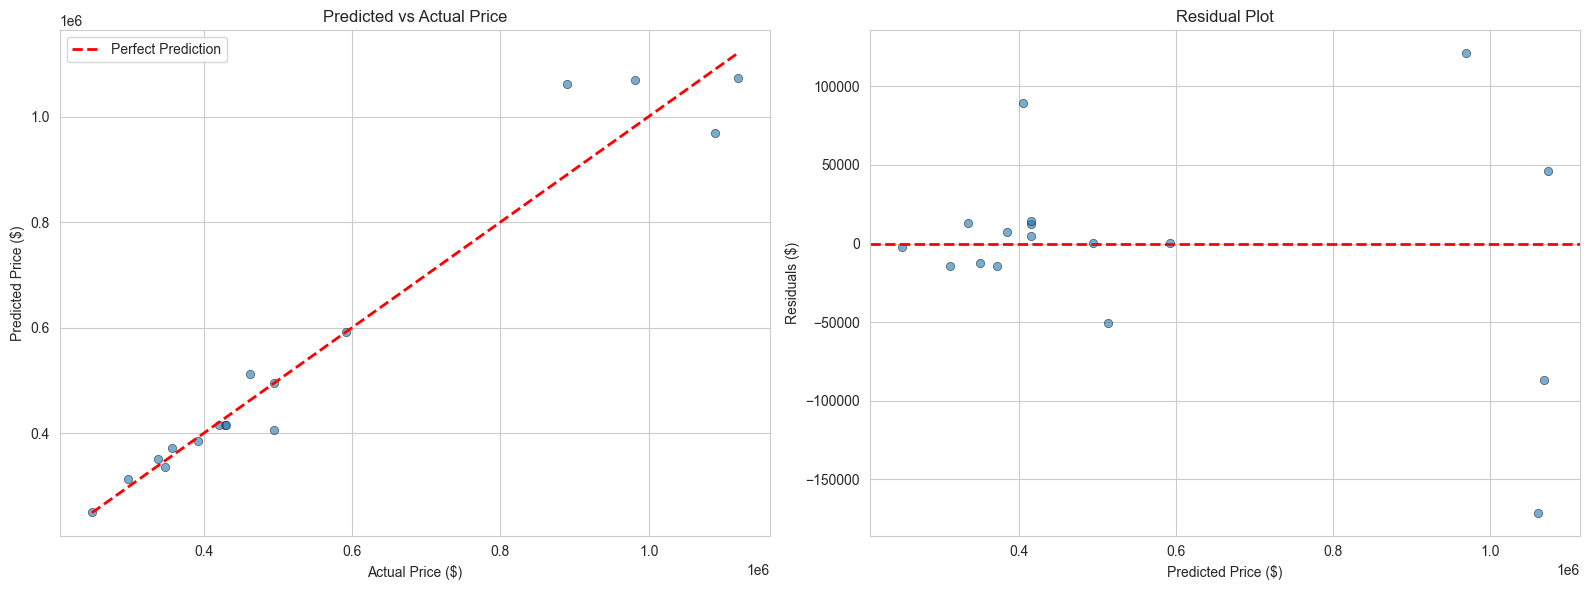


Residual Statistics:
  Mean: $   -2,553.01
  Std:  $   63,949.36
  Min:  $ -171,335.62
  Max:  $  121,069.62


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test_orig, y_pred_test, alpha=0.6, edgecolor='k', linewidth=0.5)
min_val = min(y_test_orig.min(), y_pred_test.min())
max_val = max(y_test_orig.max(), y_pred_test.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Predicted vs Actual Price')
axes[0].legend()

residuals = y_test_orig - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.6, edgecolor='k', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Price ($)')
axes[1].set_ylabel('Residuals ($)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

print(f'\nResidual Statistics:')
print(f'  Mean: ${residuals.mean():>12,.2f}')
print(f'  Std:  ${residuals.std():>12,.2f}')
print(f'  Min:  ${residuals.min():>12,.2f}')
print(f'  Max:  ${residuals.max():>12,.2f}')

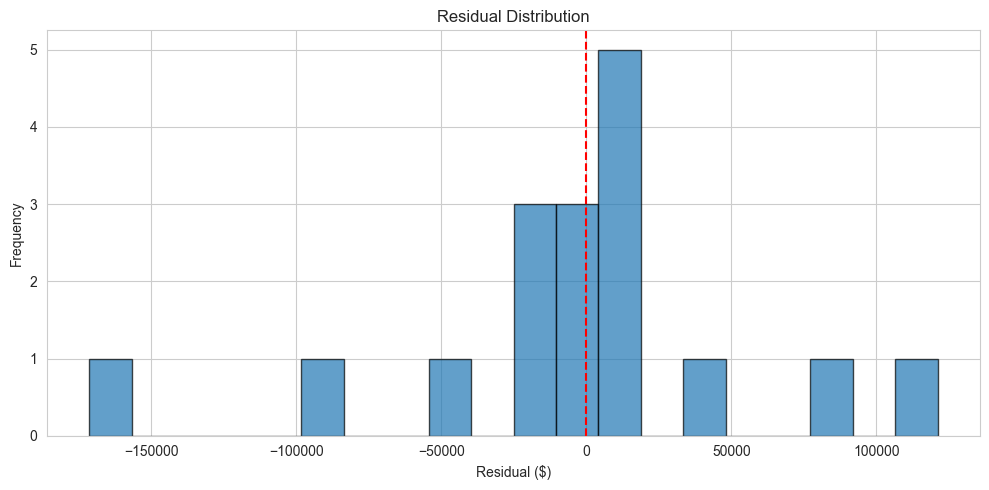

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
ax.set_title('Residual Distribution')
ax.set_xlabel('Residual ($)')
ax.set_ylabel('Frequency')
ax.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

## 1.6.4 Feature Importance

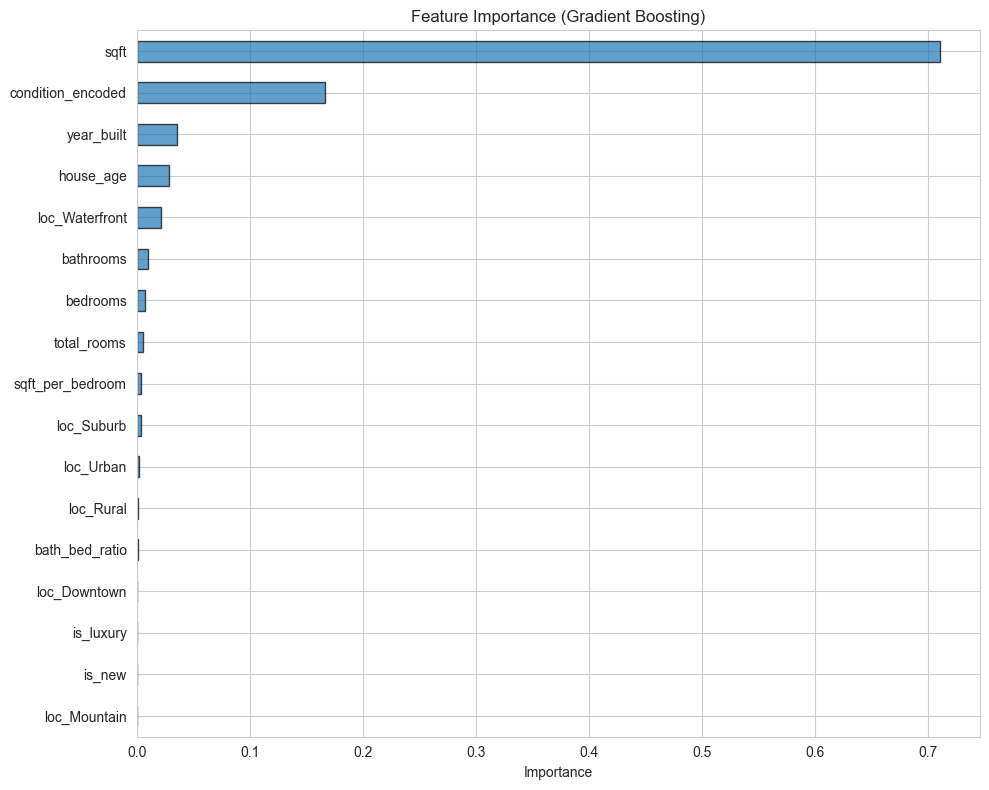

In [6]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
    importances = importances.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    importances.plot(kind='barh', ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(f'Feature Importance ({best_model_name})')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    coefs = pd.Series(np.abs(best_model.coef_), index=FEATURE_COLS)
    coefs = coefs.sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    coefs.plot(kind='barh', ax=ax, edgecolor='black', alpha=0.7)
    ax.set_title(f'Feature Coefficients ({best_model_name})')
    ax.set_xlabel('|Coefficient|')
    plt.tight_layout()
    plt.show()
else:
    print('Model does not expose feature importance or coefficients.')

## 1.6.5 Experiment Summary

In [7]:
print('\n' + '='*60)
print('EXPERIMENT SUMMARY')
print('='*60)
print(f'Best Model: {best_model_name}')
print(f'Best CV R2: {experiment_results["best_cv_r2"]:.4f}')
print(f'Best Test R2: {test_r2:.4f}')
print(f'Best Test RMSE: ${test_rmse:,.2f}')
print(f'Best Test MAE: ${test_mae:,.2f}')
print(f'Best Test MAPE: {test_mape*100:.2f}%')
print(f'Number of features: {len(FEATURE_COLS)}')
print(f'Training samples: {X_train.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')
print('='*60)


EXPERIMENT SUMMARY
Best Model: Gradient Boosting
Best CV R2: 0.9984
Best Test R2: 0.9489
Best Test RMSE: $62,092.50
Best Test MAE: $38,910.69
Best Test MAPE: 5.81%
Number of features: 17
Training samples: 67
Test samples: 17
